In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.api import OLS, add_constant
from statsmodels.tsa.arima.api import ARIMA

In [4]:
def normal_log_returns(T):
    return np.random.normal(loc=0.0004, scale=0.1**2, size=T)


def jump_log_returns(mu, sigma, p, mu_j, sigma_j, T):
    bt = np.random.binomial(n=1, p=1-p, size=T)
    jt = bt * (mu_j + sigma_j * np.random.normal(loc=0, scale=1, size=T))
    rt = mu + sigma * np.random.normal(loc=0, scale=1, size=T) + jt
    return rt

In [5]:
jump_sim = jump_log_returns(0.0004, 0.01, 0.01, -0.03, 0.04, 2500)
log_ret = normal_log_returns(12_500)
t = np.linspace(1, 12500/1000, num=len(log_ret))
t2 = np.linspace(1, 2500/1000, num=len(jump_sim))
real_returns = pd.read_csv('homework3data.csv')
real_returns['year'] = real_returns['year'].astype(str)
real_returns['month'] = real_returns['month'].astype(str)
real_returns['date'] = real_returns['year'] + '-' + real_returns['month']
real_returns['date'] = pd.to_datetime(real_returns['date'], format='%Y-%m')

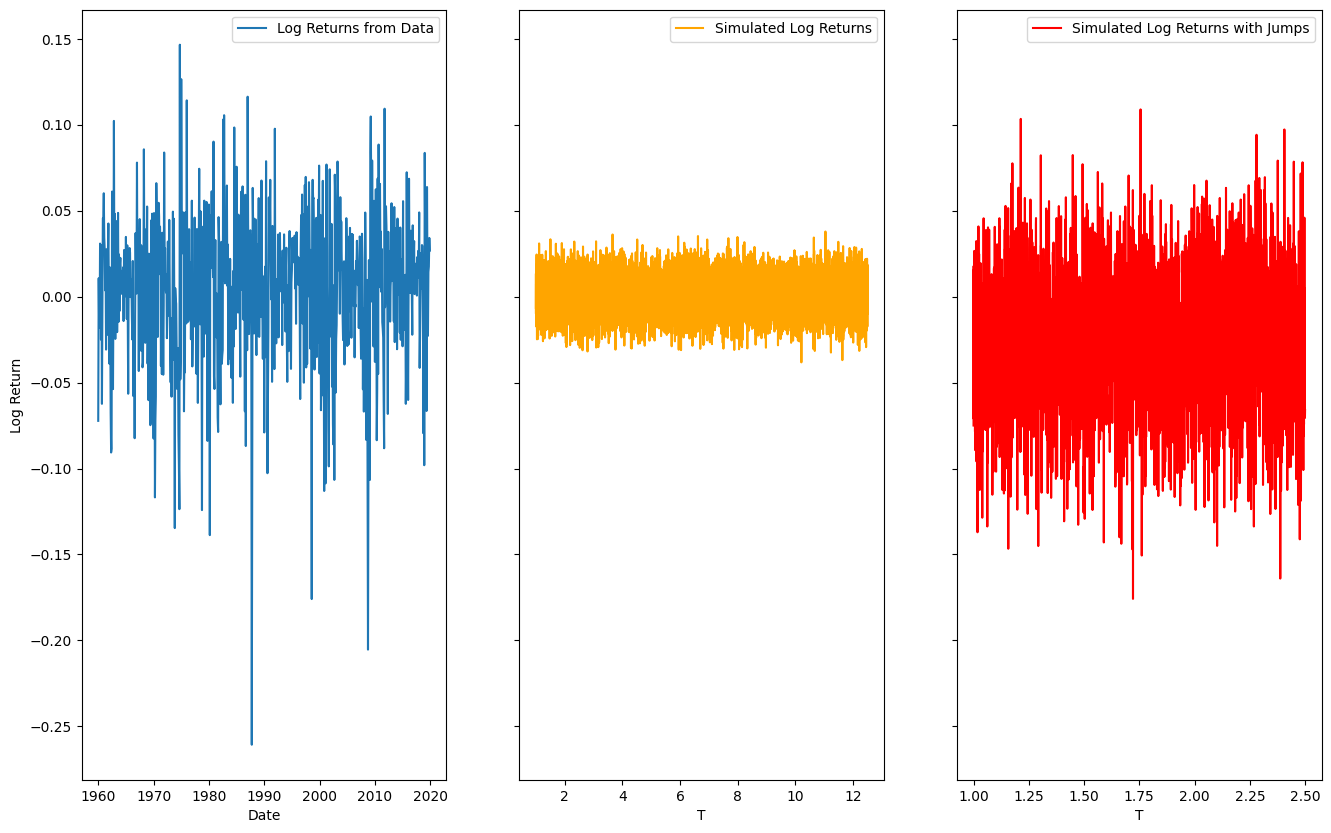

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 10), sharey=True)
sns.lineplot(data=real_returns, x='date', y='log_excess_ret', ax=axes[0], label='Log Returns from Data')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Log Return')
sns.lineplot(x=t, y=log_ret, label='Simulated Log Returns', ax=axes[1], color='orange')
axes[1].set_xlabel('T')
sns.lineplot(x=t2, y=jump_sim, label='Simulated Log Returns with Jumps', ax=axes[2], color='red')
axes[2].set_xlabel('T')
plt.show()

# Question 2

In [9]:
real_returns['rt+1'] = real_returns['log_excess_ret'].shift(1) * 12
real_returns.dropna(inplace=True)
X = real_returns['div_yld']
X = add_constant(X)
X.columns = ['alpha', 'dividend_yield']
y = real_returns['rt+1']

In [10]:
reg = OLS(y, X).fit(cov_type='HC3')
reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   rt+1   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     5.218
Date:                Fri, 13 Feb 2026   Prob (F-statistic):             0.0226
Time:                        17:58:36   Log-Likelihood:                -557.43
No. Observations:                 719   AIC:                             1119.
Df Residuals:                     717   BIC:                             1128.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
alpha              0.1984      0.064      3.098      0.002       0.073       0.324
dividend_yield    -5.2511      2.299     -2.284      0.022      -9.757      -0.745
==============================================================================
Omnibus:                      108.222   Durbin-Watson:                   1.850
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              304.555
Skew:                          -0.753   Prob(JB):                     7.36e-67
Kurtosis:                       5.810   Cond. No.                         101.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

In [11]:
print(reg.t_test('dividend_yield = 0'))

                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0            -5.2511      2.299     -2.284      0.022      -9.757      -0.745


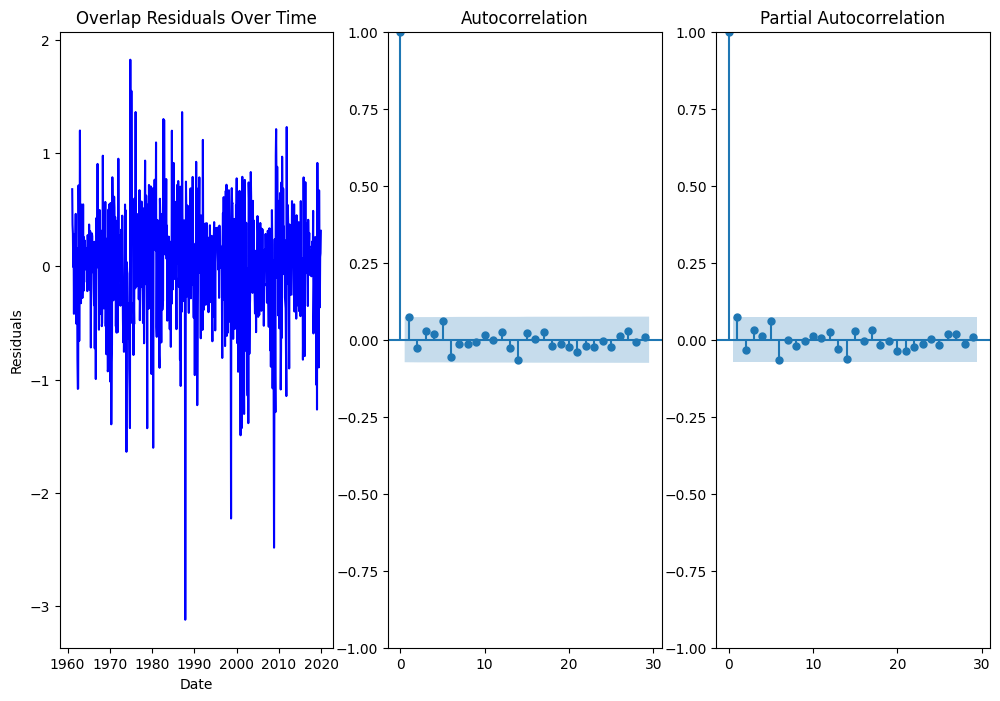

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(12, 8))
sns.lineplot(x=real_returns['date'], y=reg.resid, ax=axes[0], color='blue')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Overlap Residuals Over Time')
acf = plot_acf(x=reg.resid, ax=axes[1])
pacf = plot_pacf(x=reg.resid, ax=axes[2])
plt.show()

In [13]:
rtk_k = real_returns['log_excess_ret'].shift(1)
for i in range(2, 13):
    rtk_k += real_returns['log_excess_ret'].shift(i)

real_returns['rtk_k'] = rtk_k
real_returns.dropna(inplace=True)

In [14]:
X = add_constant(real_returns['div_yld'])
X.columns = ['alpha', 'dividend_yield']
y = real_returns['rtk_k']

In [15]:
overlap_reg = OLS(y, X).fit(cov_type='HC3')

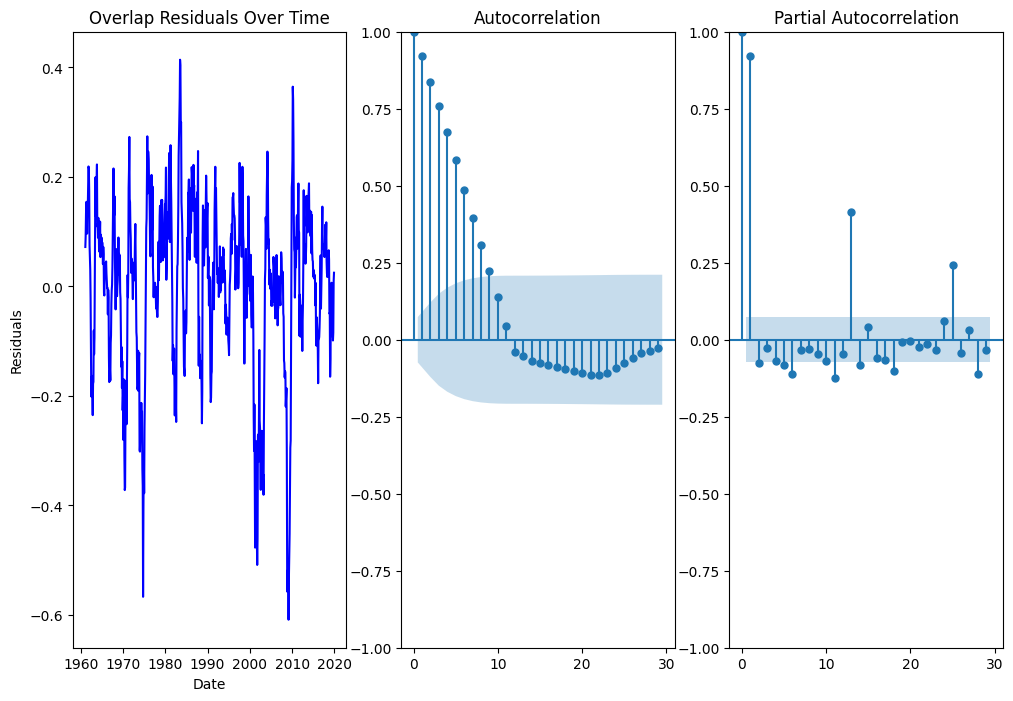

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(12, 8))
sns.lineplot(x=real_returns['date'], y=overlap_reg.resid, ax=axes[0], color='blue')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Overlap Residuals Over Time')
acf = plot_acf(x=overlap_reg.resid, ax=axes[1])
pacf = plot_pacf(x=overlap_reg.resid, ax=axes[2])
plt.show()

In [19]:
print(overlap_reg.t_test('dividend_yield = 0'))

                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0            -4.5163      0.658     -6.860      0.000      -5.807      -3.226


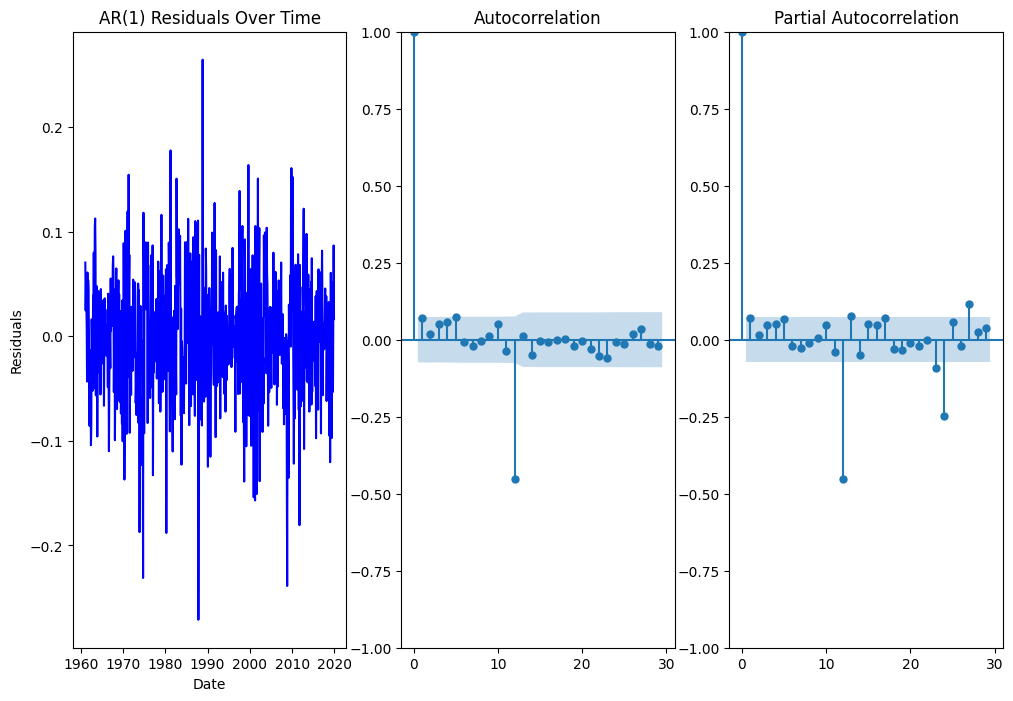

In [27]:
arima = ARIMA(overlap_reg.resid, order=(1, 0, 0)).fit()
fig, axes = plt.subplots(1, 3, figsize=(12, 8))
sns.lineplot(x=real_returns['date'], y=arima.resid, ax=axes[0], color='blue')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Residuals')
axes[0].set_title('AR(1) Residuals Over Time')
acf = plot_acf(x=arima.resid, ax=axes[1])
pacf = plot_pacf(x=arima.resid, ax=axes[2])
plt.show()